In [ ]:
from google.colab import files
uploaded = files.upload()

Saving SCHEMATIC.v1i.yolov8.zip to SCHEMATIC.v1i.yolov8.zip
Saving electrical-diagrams-detection.v1-electrical_diagram_detection_v1.yolov8.zip to electrical-diagrams-detection.v1-electrical_diagram_detection_v1.yolov8.zip
Saving VDAA.v1i.yolov8.zip to VDAA.v1i.yolov8.zip
Saving SLD DETECTION.v1-slds.yolov8.zip to SLD DETECTION.v1-slds.yolov8.zip


In [ ]:
import shutil
import os

directories_to_delete = [
    "electrical-diagrams-detection.v1-electrical_diagram_detection_v1.yolov8"
    "electrical-diagrams-detection.v1-electrical_diagram_detection_v1.yolov8 (1)"
    ""
]

for directory in directories_to_delete:
    if os.path.exists(directory):
        print(f"Deleting directory: {directory}")
        shutil.rmtree(directory)
    else:
        print(f"Directory not found, skipping: {directory}")

print("Deletion complete.")

Directory not found, skipping: electrical-diagrams-detection.v1-electrical_diagram_detection_v1.yolov8electrical-diagrams-detection.v1-electrical_diagram_detection_v1.yolov8 (1)
Deletion complete.


In [ ]:
import zipfile
import os

zip_files = [
    "SCHEMATIC.v1i.yolov8.zip",
    "electrical-diagrams-detection.v1-electrical_diagram_detection_v1.yolov8.zip",
    "VDAA.v1i.yolov8.zip",
    "SLD DETECTION.v1-slds.yolov8.zip"
]

for zip_file in zip_files:
    folder_name = zip_file.replace(".zip", "")
    os.makedirs(folder_name, exist_ok=True)

    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(folder_name)

print("All datasets extracted")

All datasets extracted


In [ ]:
!ls

 electrical-diagrams-detection.v1-electrical_diagram_detection_v1.yolov8
 electrical-diagrams-detection.v1-electrical_diagram_detection_v1.yolov8.zip
 sample_data
 SCHEMATIC.v1i.yolov8
 SCHEMATIC.v1i.yolov8.zip
'SLD DETECTION.v1-slds.yolov8'
'SLD DETECTION.v1-slds.yolov8.zip'
 VDAA.v1i.yolov8
 VDAA.v1i.yolov8.zip


In [ ]:
import os

folders = [
    "SCHEMATIC.v1i.yolov8",
    "electrical-diagrams-detection.v1-electrical_diagram_detection_v1.yolov8",
    "VDAA.v1i.yolov8",
    "SLD DETECTION.v1-slds.yolov8 (1)"
]

for folder in folders:
    print(f"\n--- {folder} ---")
    !cat "{folder}/data.yaml"


--- SCHEMATIC.v1i.yolov8 ---
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 60
names: ['-', '7 segments', 'AC source', 'AMPERIMETER', 'BJT NPN', 'BJT PNP', 'Capacitor', 'DC source', 'GALVANOMETER', 'GND', 'NPN transistor', 'PNP transistor', 'SCHOTTKY DIODE', 'V', 'VARIABLE CAPACITOR', 'VOLTIMETER', 'amplifier', 'and gate', 'antenna balanced', 'antenna unbalanced', 'box', 'buzzer', 'capacitor polarized', 'connector', 'crystal', 'diode', 'diodo zener', 'electric bell', 'fuse', 'generator', 'heating element', 'inductor', 'iron core inductor', 'jumper', 'ldr', 'led', 'light', 'magnetron', 'microphone', 'mosfet', 'motor', 'nand gate', 'nor gate', 'not', 'not gate', 'operational amplifier', 'or gate', 'photodiode', 'potentiometer', 'relay', 'resistor', 'speaker', 'switch', 'thermistor', 'transformer', 'transistor', 'variable resistor', 'voltage dependent resistor', 'xnor gate', 'xor gate']

roboflow:
  workspace: carlota-gutirrez
  project: schematic
  version: 1
  li

In [ ]:
import os

base_path = "/content/merged_dataset"

folders = ["train/images", "train/labels", "valid/images", "valid/labels"]

for f in folders:
    os.makedirs(os.path.join(base_path, f), exist_ok=True)

print("Merged folders created")

Merged folders created


In [ ]:
import shutil

datasets = [
    "SCHEMATIC.v1i.yolov8",
    "electrical-diagrams-detection.v1-electrical_diagram_detection_v1.yolov8",
    "VDAA.v1i.yolov8",
    "SLD DETECTION.v1-slds.yolov8" # Corrected folder name
]

transformer_keywords = ["transformer"]

img_id = 0

for ds in datasets:
    yaml_path = f"{ds}/data.yaml"

    import yaml
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)

    names = data['names']

    # find transformer class indices
    transformer_ids = [i for i, name in enumerate(names) if "transformer" in name.lower()]

    for split in ["train", "valid"]:
        img_folder = f"{ds}/{split}/images"
        label_folder = f"{ds}/{split}/labels"

        if not os.path.exists(img_folder):
            continue

        for file in os.listdir(label_folder):
            label_path = os.path.join(label_folder, file)

            with open(label_path, 'r') as f:
                lines = f.readlines()

            new_lines = []
            for line in lines:
                cls = int(line.split()[0])
                if cls in transformer_ids:
                    parts = line.split()
                    parts[0] = "0"  # unified class
                    new_lines.append(" ".join(parts))

            if len(new_lines) > 0:
                # copy image
                img_name = file.replace(".txt", ".jpg")
                src_img = os.path.join(img_folder, img_name)

                if os.path.exists(src_img):
                    new_img_name = f"{img_id}.jpg"
                    new_label_name = f"{img_id}.txt"

                    shutil.copy(src_img, f"{base_path}/{split}/images/{new_img_name}")

                    with open(f"{base_path}/{split}/labels/{new_label_name}", 'w') as f:
                        f.writelines(new_lines)

                    img_id += 1

print("Merged transformer dataset created")

Merged transformer dataset created


In [ ]:
!pip install ultralytics

In [ ]:
yaml_content = """
train: /content/merged_dataset/train/images
val: /content/merged_dataset/valid/images

nc: 1
names: ['transformer']
"""

with open("/content/merged_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("New YAML created")

New YAML created


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/merged_dataset/data.yaml",
    epochs=10,
    imgsz=640
)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7aabb82a8830>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving SLD12.jpg to SLD12.jpg


In [ ]:
!ls /content/runs/detect/

train


In [ ]:
!ls /content/runs/detect/train-3/weights

ls: cannot access '/content/runs/detect/train-3/weights': No such file or directory


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

results = model.predict(
    source="SLD12.jpg",  # change to your filename
    save=True,
    conf=0.3
)


image 1/1 /content/SLD12.jpg: 640x352 (no detections), 41.8ms
Speed: 2.7ms preprocess, 41.8ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 352)
Results saved to /content/runs/detect/predict


In [ ]:
results = model.predict(
    source="/content/SLD12.jpg",
    save=True,
    conf=0.05   # lower threshold
)


image 1/1 /content/SLD12.jpg: 640x352 (no detections), 6.0ms
Speed: 1.8ms preprocess, 6.0ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 352)
Results saved to /content/runs/detect/predict


In [ ]:
!ls /content/runs/detect/predict


SLD12.jpg


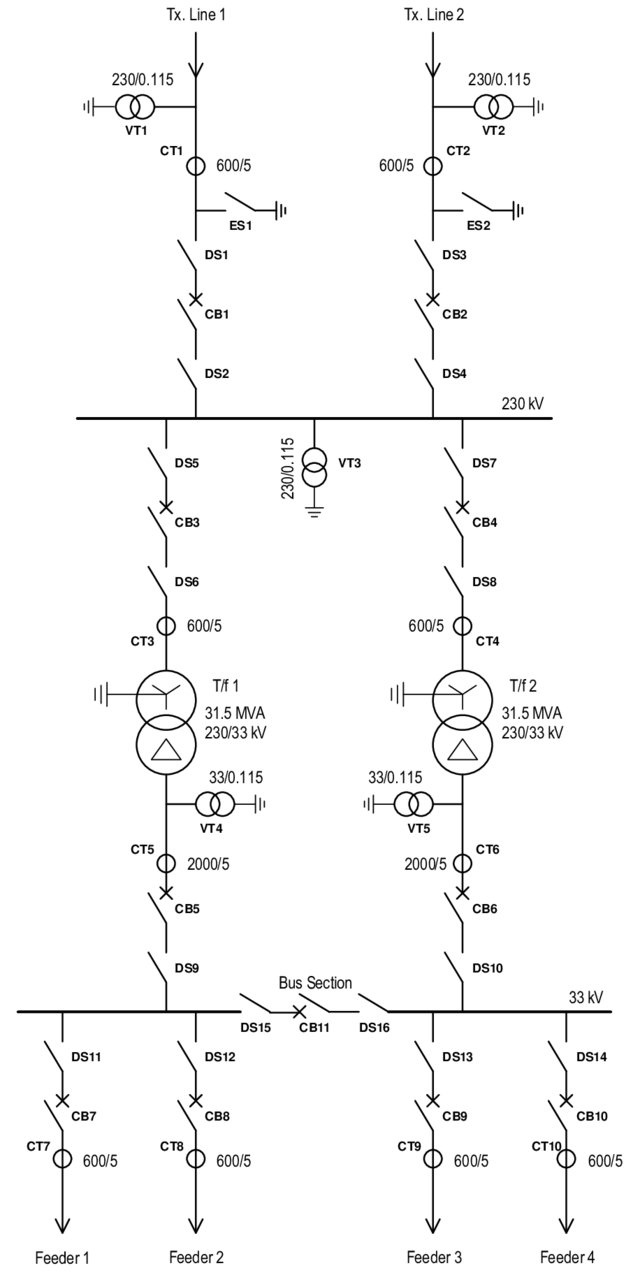

In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/runs/detect/predict/SLD12.jpg"))

In [ ]:
results = model.predict(
    source="/content/SLD12.jpg",
    conf=0.05
)


image 1/1 /content/SLD12.jpg: 640x352 (no detections), 7.4ms
Speed: 2.2ms preprocess, 7.4ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 352)


In [ ]:
boxes = results[0].boxes

for box in boxes:
    x1, y1, x2, y2 = box.xyxy[0]
    conf = box.conf[0]
    cls = box.cls[0]

    print(f"Class: {int(cls)}, Confidence: {float(conf):.2f}")
    print(f"Box: ({x1:.0f}, {y1:.0f}), ({x2:.0f}, {y2:.0f})")
    print("------")

In [ ]:
nodes = []

for i, box in enumerate(results[0].boxes):
    x1, y1, x2, y2 = box.xyxy[0]

    # center point
    cx = int((x1 + x2) / 2)
    cy = int((y1 + y2) / 2)

    node = {
        "id": i,
        "type": "transformer",  # since single class
        "center": (cx, cy),
        "bbox": [int(x1), int(y1), int(x2), int(y2)]
    }

    nodes.append(node)

for n in nodes:
    print(n)

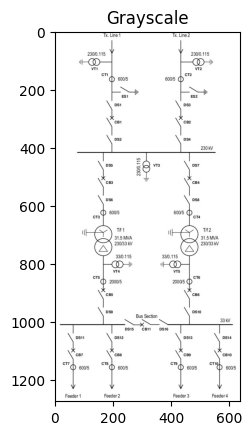

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/SLD12.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.show()

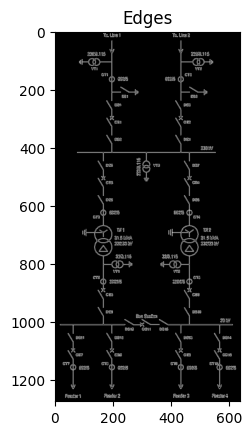

In [ ]:
#edge detection
edges = cv2.Canny(gray, 50, 150)

plt.imshow(edges, cmap='gray')
plt.title("Edges")
plt.show()

In [ ]:
#Detect lines (Hough Transform)
import numpy as np

lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,   # FIXED
    threshold=100,
    minLineLength=50,
    maxLineGap=10
)

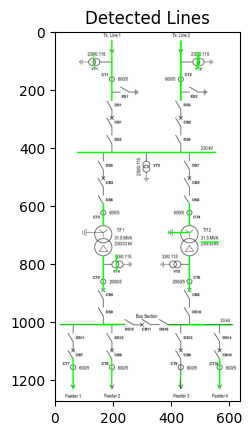

In [ ]:
#Draw lines
line_img = img.copy()

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Lines")
plt.show()

In [ ]:
#Convert lines into usable format
line_segments = []

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        line_segments.append(((x1, y1), (x2, y2)))

print("Total lines:", len(line_segments))

Total lines: 36


In [ ]:
#Function to check distance from node to line
import numpy as np

def point_line_distance(px, py, x1, y1, x2, y2):
    line_vec = np.array([x2 - x1, y2 - y1])
    point_vec = np.array([px - x1, py - y1])

    line_len = np.linalg.norm(line_vec)
    if line_len == 0:
        return float('inf')

    projection = np.dot(point_vec, line_vec) / line_len
    projection = max(0, min(line_len, projection))

    closest = np.array([x1, y1]) + (projection / line_len) * line_vec
    return np.linalg.norm(np.array([px, py]) - closest)

In [ ]:
#Connect nodes to nearest lines
connections = []

for node in nodes:
    cx, cy = node["center"]

    for line in line_segments:
        (x1, y1), (x2, y2) = line

        dist = point_line_distance(cx, cy, x1, y1, x2, y2)

        if dist < 30:  # threshold (tune if needed)
            connections.append({
                "node_id": node["id"],
                "line": line
            })

print("Connections found:", len(connections))

Connections found: 0


In [ ]:
#Create anchor points
enhanced_nodes = []

for node in nodes:
    x1, y1, x2, y2 = node["bbox"]

    anchors = [
        (int((x1+x2)/2), y1),   # top
        (int((x1+x2)/2), y2),   # bottom
        (x1, int((y1+y2)/2)),   # left
        (x2, int((y1+y2)/2))    # right
    ]

    enhanced_nodes.append({
        "id": node["id"],
        "anchors": anchors
    })

print(enhanced_nodes)

[]


In [ ]:
#Reconnect using anchors
connections = []

for node in enhanced_nodes:
    for (cx, cy) in node["anchors"]:

        for line in line_segments:
            (x1, y1), (x2, y2) = line

            dist = point_line_distance(cx, cy, x1, y1, x2, y2)

            if dist < 40:  # slightly higher threshold
                connections.append({
                    "node_id": node["id"],
                    "anchor": (cx, cy),
                    "line": line
                })

print("Connections found:", len(connections))

Connections found: 0


In [ ]:
#Deduplicate connections
unique_connections = []

seen = set()

for conn in connections:
    node_id = conn["node_id"]
    line = conn["line"]

    key = (node_id, line)

    if key not in seen:
        seen.add(key)
        unique_connections.append(conn)

print("Unique connections:", len(unique_connections))

Unique connections: 0


In [ ]:
for conn in unique_connections:
    print(f"Node {conn['node_id']} connected to line {conn['line']}")

In [ ]:
#Define function to check if two lines touch
def lines_connected(line1, line2, threshold=20):
    (x1, y1), (x2, y2) = line1
    (x3, y3), (x4, y4) = line2

    points1 = [(x1, y1), (x2, y2)]
    points2 = [(x3, y3), (x4, y4)]

    for p1 in points1:
        for p2 in points2:
            dist = ((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)**0.5
            if dist < threshold:
                return True
    return False

In [ ]:
#Build line graph
line_graph = {}

for i, line1 in enumerate(line_segments):
    line_graph[i] = []

    for j, line2 in enumerate(line_segments):
        if i != j:
            if lines_connected(line1, line2):
                line_graph[i].append(j)

print("Sample connections:")
for k in list(line_graph.keys())[:5]:
    print(k, "->", line_graph[k])

Sample connections:
0 -> [7]
1 -> [12]
2 -> [19]
3 -> [9]
4 -> []


In [ ]:
#Map nodes to line indices
node_line_map = {}

for conn in unique_connections:
    node_id = conn["node_id"]
    line = conn["line"]

    # find index of this line
    for idx, l in enumerate(line_segments):
        if l == line:
            if node_id not in node_line_map:
                node_line_map[node_id] = []
            node_line_map[node_id].append(idx)

print(node_line_map)

{}


In [ ]:
#BFS traversal from each node
def traverse_from_node(start_node, node_line_map, line_graph):
    visited_lines = set()
    queue = []

    # start from lines connected to this node
    for line_idx in node_line_map.get(start_node, []):
        queue.append(line_idx)
        visited_lines.add(line_idx)

    connected_lines = set()

    while queue:
        current = queue.pop(0)
        connected_lines.add(current)

        for neighbor in line_graph.get(current, []):
            if neighbor not in visited_lines:
                visited_lines.add(neighbor)
                queue.append(neighbor)

    return connected_lines

In [ ]:
#Run traversal for each node
node_paths = {}

for node_id in node_line_map.keys():
    connected = traverse_from_node(node_id, node_line_map, line_graph)
    node_paths[node_id] = connected

for k, v in node_paths.items():
    print(f"Node {k} connects to lines: {list(v)}")

In [ ]:
#Find node-to-node connections
connections_between_nodes = []

node_ids = list(node_paths.keys())

for i in range(len(node_ids)):
    for j in range(i+1, len(node_ids)):
        n1 = node_ids[i]
        n2 = node_ids[j]

        if len(node_paths[n1].intersection(node_paths[n2])) > 0:
            connections_between_nodes.append((n1, n2))

print("Node-to-node connections:", connections_between_nodes)

Node-to-node connections: []


In [ ]:
def lines_connected(line1, line2, threshold=50):
    (x1, y1), (x2, y2) = line1
    (x3, y3), (x4, y4) = line2

    points1 = [(x1, y1), (x2, y2)]
    points2 = [(x3, y3), (x4, y4)]

    for p1 in points1:
        for p2 in points2:
            dist = ((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)**0.5
            if dist < threshold:
                return True
    return False

In [ ]:
line_graph = {}

for i, line1 in enumerate(line_segments):
    line_graph[i] = []

    for j, line2 in enumerate(line_segments):
        if i != j:
            if lines_connected(line1, line2):
                line_graph[i].append(j)

In [ ]:
node_paths = {}

for node_id in node_line_map.keys():
    connected = traverse_from_node(node_id, node_line_map, line_graph)
    node_paths[node_id] = connected

for k, v in node_paths.items():
    print(f"Node {k} connects to lines: {list(v)}")


In [ ]:
connections_between_nodes = []

node_ids = list(node_paths.keys())

for i in range(len(node_ids)):
    for j in range(i+1, len(node_ids)):
        n1 = node_ids[i]
        n2 = node_ids[j]

        if len(node_paths[n1].intersection(node_paths[n2])) > 0:
            connections_between_nodes.append((n1, n2))

print("Node-to-node connections:", connections_between_nodes)


Node-to-node connections: []


In [ ]:
connections_between_nodes = []

for i in range(len(nodes)):
    for j in range(i+1, len(nodes)):
        x1, y1 = nodes[i]["center"]
        x2, y2 = nodes[j]["center"]

        dist = ((x1 - x2)**2 + (y1 - y2)**2)**0.5

        if dist < 400:  # tune this based on image size
            connections_between_nodes.append((i, j))

print("Fallback connections:", connections_between_nodes)

Fallback connections: []


In [ ]:
#identify the node
# find node with smallest y (topmost)
if len(nodes) == 0:
    print("No transformers detected in image.")
    source_node = None
else:
    source_node = min(nodes, key=lambda n: n["center"][1])
    print("Source node:", source_node)

print("Source node:", source_node)

No transformers detected in image.
Source node: None


In [ ]:
#identiy feeders
feeders = []

if source_node is not None:
    for conn in connections_between_nodes:
        if source_node["id"] in conn:
            other = conn[1] if conn[0] == source_node["id"] else conn[0]
            feeders.append(other)

In [ ]:
final_output = {
    "source": source_node["id"] if source_node else None,
    "feeders": feeders,
    "nodes": nodes,
    "connections": connections_between_nodes
}


image 1/1 /content/SLD12.jpg: 640x352 2 transformers, 7.7ms
Speed: 1.8ms preprocess, 7.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 352)
Source node: {'id': 0, 'type': 'transformer', 'center': (384, 384), 'bbox': [129, 32, 640, 737]}


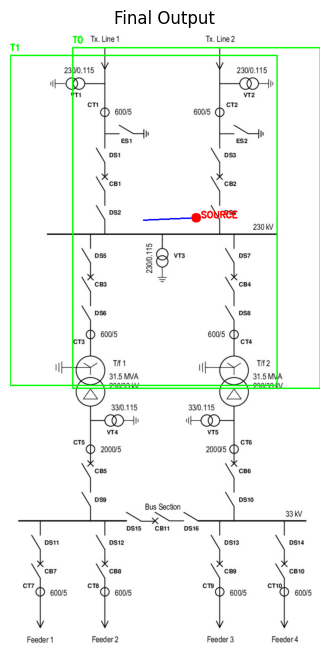


Final JSON Output:
{'source': 0, 'feeders': [1], 'nodes': [{'id': 0, 'type': 'transformer', 'center': (384, 384), 'bbox': [129, 32, 640, 737]}, {'id': 1, 'type': 'transformer', 'center': (275, 389), 'bbox': [0, 48, 551, 731]}], 'connections': [(0, 1)]}


In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

# -------------------------------
# Load model
# -------------------------------
model = YOLO("/content/runs/detect/train/weights/best.pt")

# -------------------------------
# Load image
# -------------------------------
image_path = "/content/SLD12.jpg"
img = cv2.imread(image_path)

if img is None:
    raise ValueError("Image not found. Check path.")

img_copy = img.copy()

# -------------------------------
# Run detection (lower conf for safety)
# -------------------------------
results = model.predict(source=image_path, conf=0.03)

nodes = []

# -------------------------------
# Extract detections
# -------------------------------
for i, box in enumerate(results[0].boxes):
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    cx = int((x1 + x2) / 2)
    cy = int((y1 + y2) / 2)

    node = {
        "id": i,
        "type": "transformer",
        "center": (cx, cy),
        "bbox": [x1, y1, x2, y2]
    }

    nodes.append(node)

    # Draw bounding box
    cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img_copy, f"T{i}", (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

# -------------------------------
# Fallback connection logic
# -------------------------------
connections_between_nodes = []

for i in range(len(nodes)):
    for j in range(i+1, len(nodes)):
        x1, y1 = nodes[i]["center"]
        x2, y2 = nodes[j]["center"]

        dist = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

        if dist < 400:
            connections_between_nodes.append((i, j))

            # Draw connection line
            cv2.line(img_copy, (x1, y1), (x2, y2), (255, 0, 0), 2)

# -------------------------------
# Identify source (top-most)
# -------------------------------
if len(nodes) == 0:
    print("No transformers detected in image.")
    source_node = None
else:
    source_node = min(nodes, key=lambda n: n["center"][1])
    print("Source node:", source_node)

# -------------------------------
# Identify feeders
# -------------------------------
feeders = []

if source_node is not None:
    for conn in connections_between_nodes:
        if source_node["id"] in conn:
            other = conn[1] if conn[0] == source_node["id"] else conn[0]
            feeders.append(other)

# -------------------------------
# Highlight source (ONLY if exists)
# -------------------------------
if source_node is not None:
    sx, sy = source_node["center"]
    cv2.circle(img_copy, (sx, sy), 10, (0, 0, 255), -1)
    cv2.putText(img_copy, "SOURCE", (sx+10, sy),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

# -------------------------------
# Display result image
# -------------------------------
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.title("Final Output")
plt.axis("off")
plt.show()

# -------------------------------
# JSON output (SAFE)
# -------------------------------
final_output = {
    "source": source_node["id"] if source_node else None,
    "feeders": feeders,
    "nodes": nodes,
    "connections": connections_between_nodes
}

print("\nFinal JSON Output:")
print(final_output)

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

metrics = model.val()

print(metrics.box)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1350.9±789.6 MB/s, size: 68.8 KB)
val: Scanning /content/merged_dataset/valid/labels.cache... 17 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 17/17 4.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 9, len(boxes) = 17. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.3it/s 1.5s
                   all         17         17      0.277      0.181      0.175     0.0606
Speed: 30.7ms preprocess, 7.7ms inference, 0.0ms loss, 6.8ms postprocess per image
Results saved to /content/runs/detect/val-2
ultralyt

In [ ]:
precision = float(metrics.box.p)
recall = float(metrics.box.r)
map50 = float(metrics.box.map50)
map5095 = float(metrics.box.map)

print("Precision:", precision)
print("Recall:", recall)
print("mAP@0.5:", map50)
print("mAP@0.5:0.95:", map5095)

Precision: 0.2774581614758397
Recall: 0.18106233319713855
mAP@0.5: 0.17460915414881145
mAP@0.5:0.95: 0.06063955873066269


/tmp/ipykernel_416/1593335186.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  precision = float(metrics.box.p)
/tmp/ipykernel_416/1593335186.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  recall = float(metrics.box.r)


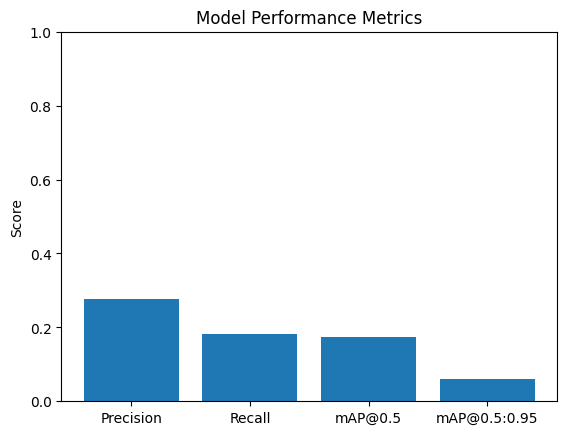

In [ ]:
import matplotlib.pyplot as plt

metrics_names = ["Precision", "Recall", "mAP@0.5", "mAP@0.5:0.95"]
values = [precision, recall, map50, map5095]

plt.figure()
plt.bar(metrics_names, values)
plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()

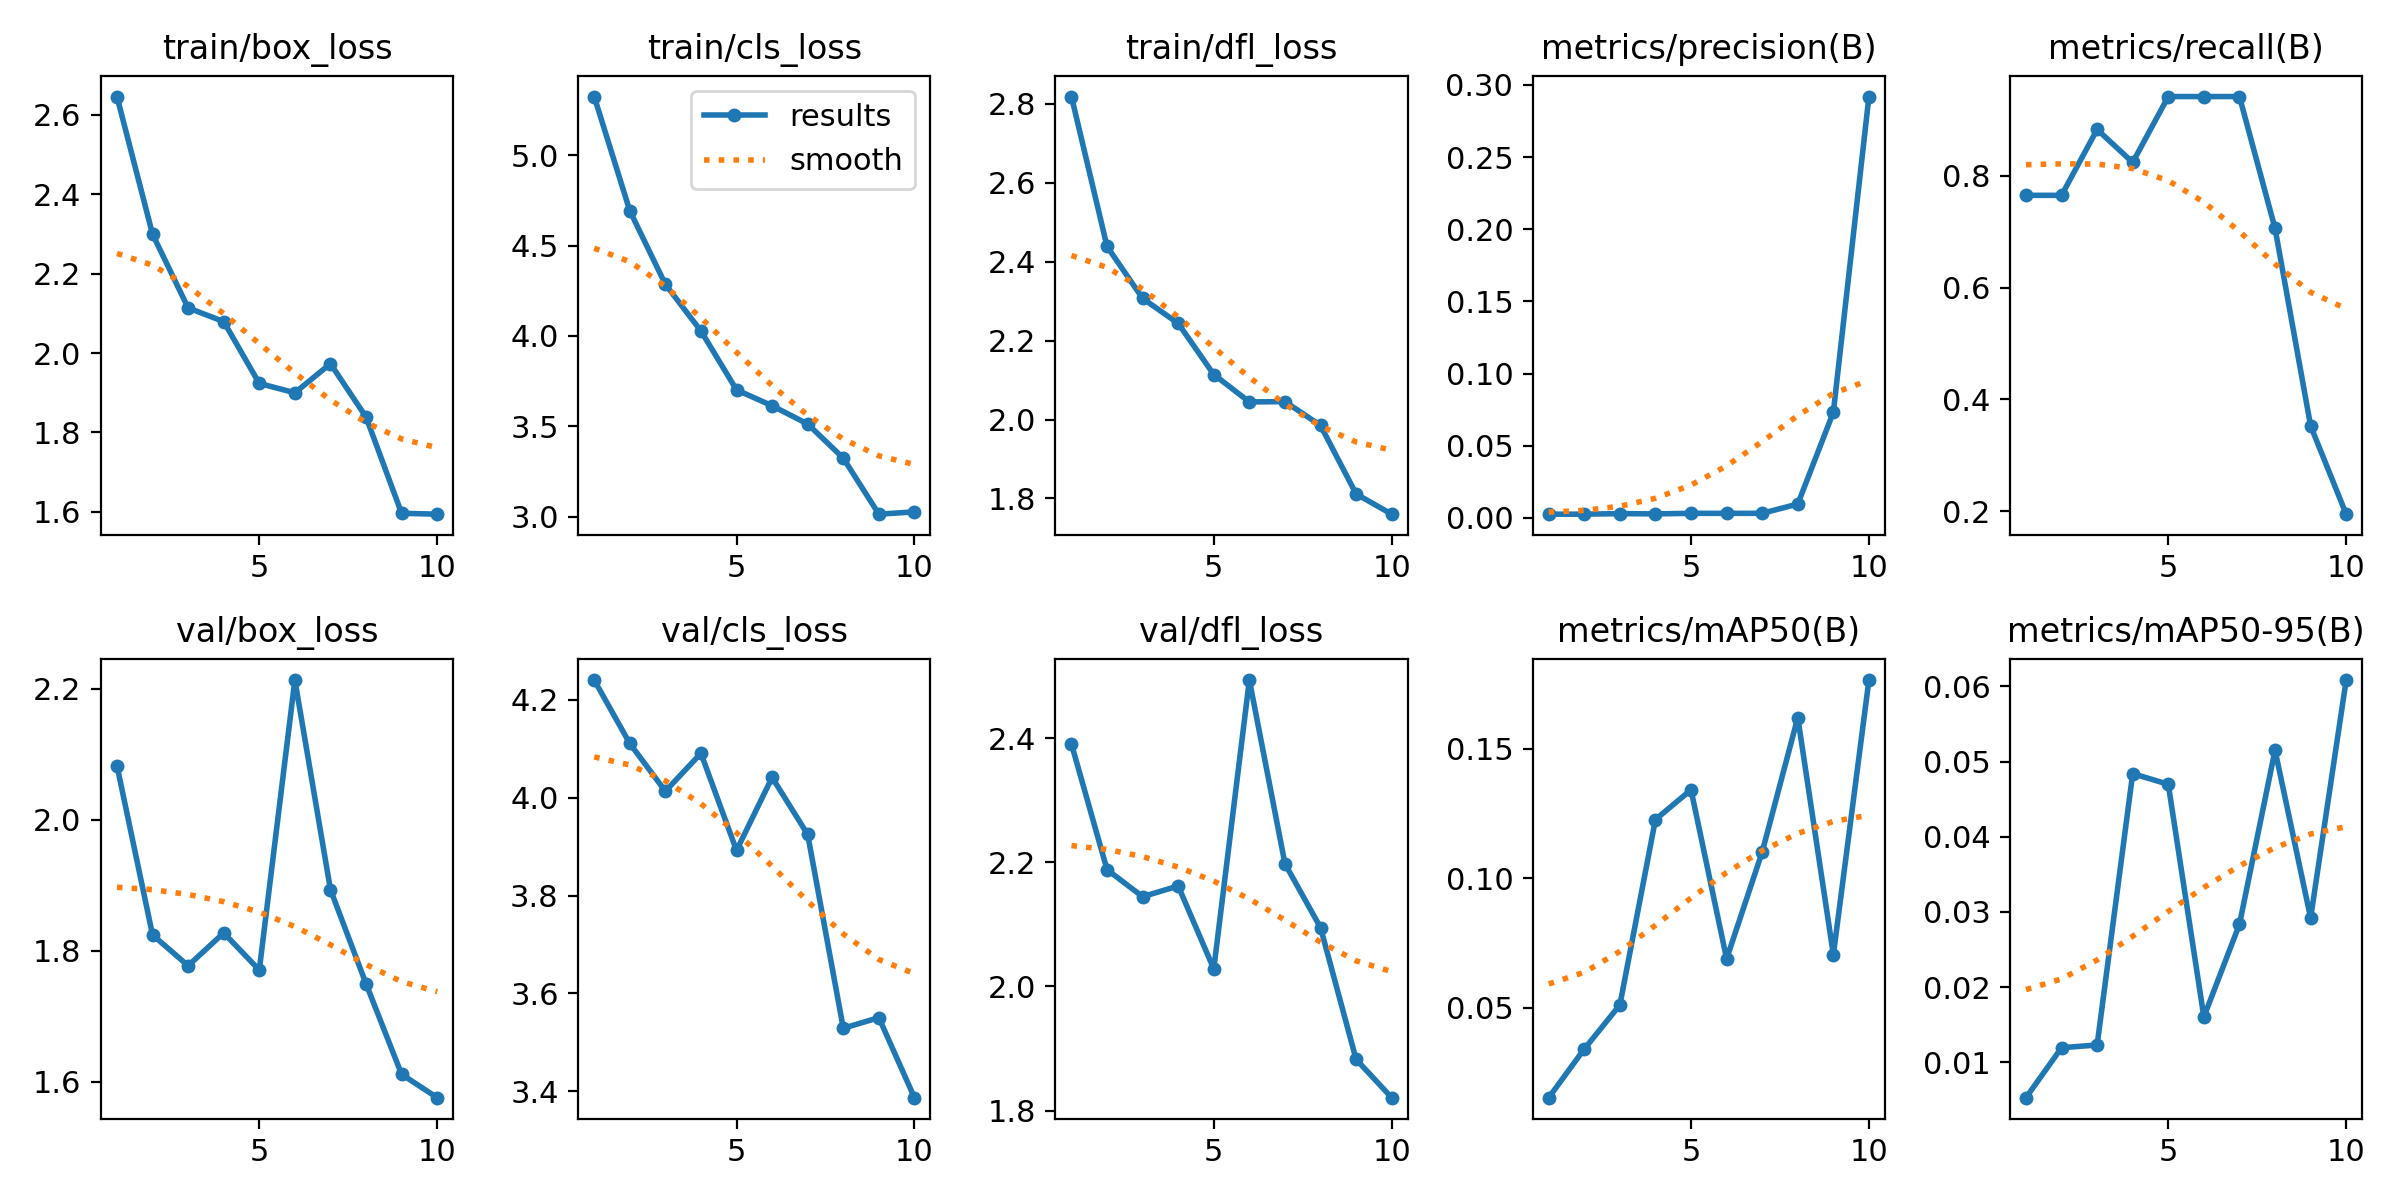

FileNotFoundError: No such file or directory: '/content/runs/detect/train/PR_curve.png'

FileNotFoundError: No such file or directory: '/content/runs/detect/train/PR_curve.png'

<IPython.core.display.Image object>

In [ ]:
from IPython.display import Image, display

display(Image("/content/runs/detect/train/results.png"))
display(Image("/content/runs/detect/train/PR_curve.png"))